In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict ,Annotated
from langchain_core.messages import BaseMessage,HumanMessage

from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    

In [3]:
load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def chat_node(state:ChatState):
    # take user query from the state
    messages =state['messages']
    
    # send to llm 
    response = llm.invoke(messages)
    
    #response store state
    return {'messages':[response]}
    

In [4]:
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile()


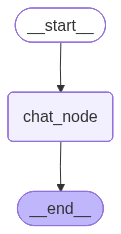

In [5]:
chatbot

In [6]:
initial_state={
    'messages':[HumanMessage(content="what is the capital of india")]
    
}
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'

# adding memory

In [7]:
from langgraph.checkpoint.memory import MemorySaver

In [8]:
checkpointer = MemorySaver()
graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)



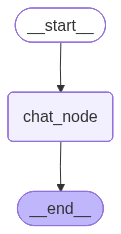

In [9]:
chatbot

In [11]:
llm=ChatGoogleGenerativeAI(model="gemini-flash-latest")


In [12]:
thread_id='1'

while True:
    
    user_message =input('Type here: ')
    
    print('User',user_message)
    
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response =chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI',response['messages'][-1].content)

User hi
AI [{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'Es8CCswCAb4+9vvYU6lJz61ZJhbl1J8xO8gWyJya2/JTgfzUWLfX7rkFoS2xjusAFDr5XwWBe0nXt0LUMbgHpj8IyCKinOBomke1jOO2jJ+efWXcAVhC3gRVih53MhqqOx8EeDrue0euf3NpHdje566a3LA8ecZEYKhOw5/rTQIs0vSCSsCy+z1vaUniw8siL5q3bfM3TkwA3bnaMkBCl4QBjCMB9gr8nmkks4HEQymJtJ/G7kD1kZSjM4zSMpTSTHvFP/AgtbGrR61sEDzEXJqynxS+B+GFxH2ZgKgXNlKz10r8tlQgHQGfgFeMp1qPNTNlyHtuMq50xksMmZaJSrbbchQ3fEPXUb4Gj6Bk/Z14xVCtv4HB91Wk3qy5iUyZGmfJ1ixN9eeVMzXxzjmPm5kjZzvXYinCrWF7RMkUKwMQJi5hb30vryI9xEohoQKF3YQ='}}]
User my name is thanuja
AI [{'type': 'text', 'text': 'Nice to meet you, Thanuja! How can I help you today?', 'extras': {'signature': 'Eo8CCowCAb4+9vtAYEMubI4XJD56sY0vhgGTMtvwt/DYr3zhY4/nfHRfKKFZrFry8Rxwrxu31wQnYh4CoTklECSymUvLdWiry8nXwmUqjM38bR7k/jIaLfgFFsSBL7wdzXH/GhR+Z0eMeVZ3twbzc++0RGBNrjYgtZcXjvlzAVKjem8yB3UxZ7Q6wymqihG7zVDevMKwDCFjOwqG6X6m+2hffv3X+FuZIzM44JF2r8x6E/I1eQkArLRBdflc0YHExkJoq7yXQLTq4/C6L1mYfE0nRd42DTk7pWVHe/+IftG4spRX0rCn

In [13]:
thread_id='1'

while True:
    
    user_message =input('Type here: ')
    
    print('User',user_message)
    
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response =chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    content = response['messages'][-1].content
    print('AI', content[0]['text'] if isinstance(content, list) else content)

User hi
AI Hello again, Thanuja! How can I help you now?
User hello
AI Hello, Thanuja! How's it going? Is there anything specific you'd like to talk about or any help you need today?
User bye


In [14]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi ', additional_kwargs={}, response_metadata={}, id='6493fb41-b645-4c09-a630-d182f0af03c4'), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='8aeb1815-61ce-4bc0-918f-ffd24e6d944d'), AIMessage(content=[{'type': 'text', 'text': 'Hi there! How can I help you today?', 'extras': {'signature': 'Es8CCswCAb4+9vvYU6lJz61ZJhbl1J8xO8gWyJya2/JTgfzUWLfX7rkFoS2xjusAFDr5XwWBe0nXt0LUMbgHpj8IyCKinOBomke1jOO2jJ+efWXcAVhC3gRVih53MhqqOx8EeDrue0euf3NpHdje566a3LA8ecZEYKhOw5/rTQIs0vSCSsCy+z1vaUniw8siL5q3bfM3TkwA3bnaMkBCl4QBjCMB9gr8nmkks4HEQymJtJ/G7kD1kZSjM4zSMpTSTHvFP/AgtbGrR61sEDzEXJqynxS+B+GFxH2ZgKgXNlKz10r8tlQgHQGfgFeMp1qPNTNlyHtuMq50xksMmZaJSrbbchQ3fEPXUb4Gj6Bk/Z14xVCtv4HB91Wk3qy5iUyZGmfJ1ixN9eeVMzXxzjmPm5kjZzvXYinCrWF7RMkUKwMQJi5hb30vryI9xEohoQKF3YQ='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='l